In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

In [2]:
from data_loading    import load_data
from elo_ratings     import compute_elo
from player_profiles import compute_player_profiles
from h2h             import compute_h2h
from features        import build_dataset, ALL_FEATURES
from training        import train_all_models, evaluate, baseline_rank, \
                            plot_results, plot_feature_importance, leakage_diagnostic
from predict         import predict_matchup

 2011 : 3,015 matches
 2012 : 3,009 matches
 2013 : 2,944 matches
 2014 : 2,901 matches
 2015 : 2,943 matches
 2016 : 2,941 matches
 2017 : 2,911 matches
 2018 : 2,897 matches
 2019 : 2,806 matches
 2020 : 1,462 matches
 2021 : 2,733 matches
 2022 : 2,917 matches
 2023 : 2,986 matches
 2024 : 3,076 matches

 total: 39,541 matches

 Elo computed — 1,550 players, 3,001 player-surface pairs
 Profiles computed — 1,550 players
 H2H computed — 79,082 player-pair-match entries
✓ Dataset built — 35,050 matches | skipped: 4,491
  y=1: 17,555  |  y=0: 17,495
Train ≤2022: 29,573  |  Test ≥2023: 5,477

 Logistic Regression

  Best params : {'clf__C': 0.01, 'clf__max_iter': 500, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
  CV AUC      : 0.7383

 Random Forest

  Best params : {'clf__max_depth': None, 'clf__min_samples_leaf': 20, 'clf__n_estimators': 300}
  CV AUC      : 0.7316

 XGBoost

  Best params : {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsampl

FileNotFoundError: [Errno 2] No such file or directory: 'results/figures/model_evaluation.png'

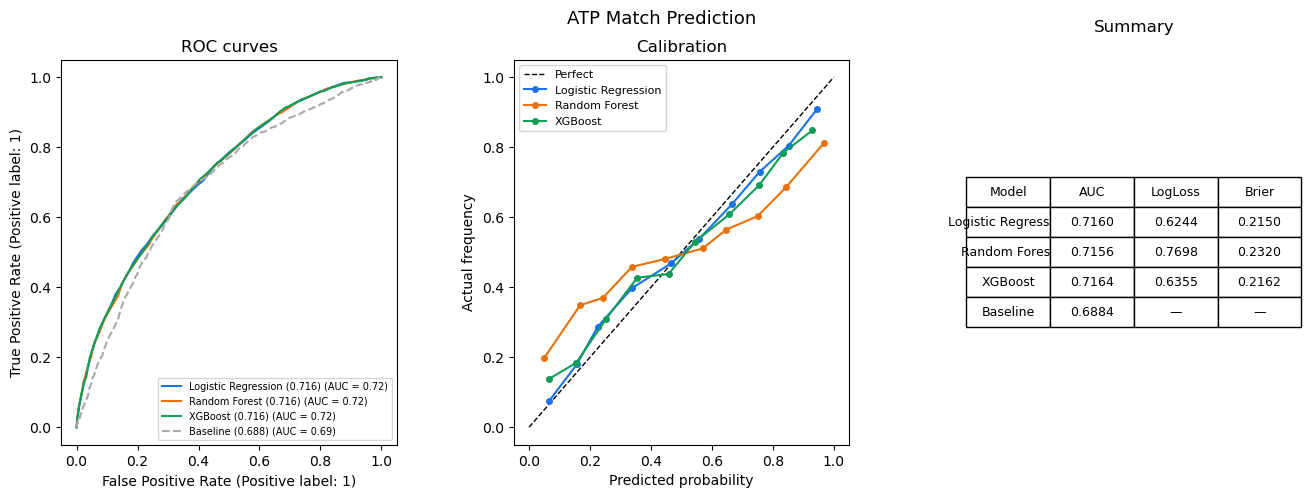

In [3]:
raw      = load_data()
elo_df   = compute_elo(raw)
profiles = compute_player_profiles(raw)
h2h      = compute_h2h(raw)
df       = build_dataset(raw, profiles, h2h, elo_df)

trained, X_train, X_test, y_train, y_test = train_all_models(df)

baseline_auc, baseline_prob = baseline_rank(X_test, y_test)
results = [evaluate(name, model, X_test, y_test) for name, model in trained.items()]
plot_results(results, baseline_auc, baseline_prob, y_test)